**Zepto Data Analysis**

**1) Business Objective**

To assess and improve the quality, consistency, and completeness of the grocery product listing data by identifying anomalies, inconsistencies, missing information, duplicates, and pricing irregularities across products, categories, stores, and locations, thereby ensuring accurate product information and enhancing the customer shopping experience.

**2) Import Libraries**

In [1]:
import pandas as pd        # For data manipulation
import numpy as np      # For numerical computations
import seaborn as sns  # For advanced visualization
import matplotlib.pyplot as plt # For plotting
import re # For regular expressions

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


**3) Import Dataset**

In [2]:
df = pd.read_csv("/home/user/Downloads/store_data/zepto_2026_06_23.csv")  #Reading Dataset from csv file

**4) Data Insights**

In [3]:
print("INFORMATION ABOUT DATASET")
print("--------------------------------")
df.info() 

INFORMATION ABOUT DATASET
--------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19034 entries, 0 to 19033
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   crawl_date_and_time      19034 non-null  object 
 1   platform_name            19034 non-null  object 
 2   store_id                 19034 non-null  object 
 3   store_name_location      19034 non-null  object 
 4   city                     19034 non-null  object 
 5   pin_code                 19034 non-null  int64  
 6   unique_id                19034 non-null  object 
 7   product_id_upc_ean       19034 non-null  object 
 8   department               19034 non-null  object 
 9   category                 19034 non-null  object 
 10  sub_category             19030 non-null  object 
 11  product_type             17873 non-null  object 
 12  brand_name               19034 non-null  object 
 13  product_name     

In [4]:
print("\nDESCRIPTIVE STATISTICS OF DATASET")
print("--------------------------------")
df.describe().T.round(2) 


DESCRIPTIVE STATISTICS OF DATASET
--------------------------------


,count,mean,std,min,25%,50%,75%,max
pin_code,19034.0,388749.89,140994.28,132103.00,411057.0,411057.0,422006.0,560091.0
item_mrp,19034.0,346.97,486.64,2.16,90.0,199.0,400.0,9999.0
item_selling_price,19034.0,255.72,325.76,2.16,73.0,159.0,308.0,5699.0
product_price,19034.0,255.72,325.76,2.16,73.0,159.0,308.0,5699.0
unit_price,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
promo_offer_price,19034.0,255.72,325.76,2.16,73.0,159.0,308.0,5699.0
discount_in_percent,19034.0,19.25,16.62,0.00,6.0,15.0,28.0,89.0
stock_count,19034.0,3.02,5.30,0.00,0.0,2.0,3.0,50.0


In [5]:
print("\nDATASET SHAPE")
print("--------------------------------")
print("The shape =", df.shape)
num_rows, num_cols = df.shape
num_features = num_cols - 1
num_data = num_rows * num_cols

# Print the information about the dataset
print(f"Number of Rows: {num_rows}")
print(f"Number of Columns: {num_cols}")
print(f"Number of Features: {num_features}")
print(f"Number of All Data: {num_data}")


DATASET SHAPE
--------------------------------
The shape = (19034, 31)
Number of Rows: 19034
Number of Columns: 31
Number of Features: 30
Number of All Data: 590054


In [7]:
print("COLUMNWISE DATA PROFILING")
print("--------------------------------")
summary = []

for col in df.columns:
    null_count = df[col].isnull().sum()
    null_percent = round((null_count / len(df)) * 100, 2)
    distinct_count = df[col].nunique(dropna=True)
    
    # Check if all non-null values are unique
    is_unique = "Yes" if df[col].is_unique and null_count == 0 else "No"


    summary.append({
        'column_name': col,
        'null_count': null_count,
        #'null_percent': null_percent,
        'distinct_count': distinct_count,
        'is_unique': is_unique
    })

summary_df = pd.DataFrame(summary)

# Display the summary
print(summary_df)

COLUMNWISE DATA PROFILING
--------------------------------
                column_name  null_count  distinct_count is_unique
0       crawl_date_and_time           0             939        No
1             platform_name           0               1        No
2                  store_id           0               5        No
3       store_name_location           0               9        No
4                      city           0               4        No
5                  pin_code           0               6        No
6                 unique_id           0            7552        No
7        product_id_upc_ean           0            7286        No
8                department           0              10        No
9                  category           0              27        No
10             sub_category           4             156        No
11             product_type        1161            1705        No
12               brand_name           0            1081        No
13             pr

In [54]:
distinct_store_pairs = df[['store_id', 'store_name_location']].drop_duplicates()
distinct_store_pairs

,store_id,store_name_location
0,a1c67132-94e3-41b9-975b-4ef4e4851406,"Ridhs Academy, Ridh's Academy, Near Vidya Samr..."
3989,a1c67132-94e3-41b9-975b-4ef4e4851406,"Keerthana Foundation (Rehabilitation Center), ..."
4033,36924e6d-5307-4b1e-af42-2143e748a664,"Hotel Tarangan, 2, Kharjul Mala, Takli Road Ja..."
7862,edbcfecc-a753-4fc8-ab8a-eb7b7d3dfbd7,"Blinkit Store HP-2, Phase 2, Hinjawadi Rajiv G..."
11527,c05fc241-12e3-417b-aa15-a13ecfc60122,"Modal Tawn, 1108, Sector 18 Rd, Sector - 18, H..."
15354,fe4a16ca-6c7c-4f1a-88a7-fecda52d8057,"Sky Fly Trampoline Park, Shankar Kalat Nagar, ..."
17463,fe4a16ca-6c7c-4f1a-88a7-fecda52d8057,"Kalpataru New Launch Pimple Nilakh, Jagtap Dai..."
18206,fe4a16ca-6c7c-4f1a-88a7-fecda52d8057,"Pimpri Chinchwad Rahatani Phata, 411017, Kalew..."
19007,fe4a16ca-6c7c-4f1a-88a7-fecda52d8057,"Akash Kiran Phase - 1, Akash Kiran, Pimple Gur..."


***Insights:***
* Shape of dataset is (19034, 31)
* Null values are present on 5 columns.
* Only the column unit_price is completely empty.
* None of the columns is unique including unique_id and product_url
* store_id has 5 distinct values, while store_name_location has 9 distinct values, which is suspicious. 
* While evaluating found that same store_id is shared with different storenames.

**5) Primary Key Analysis**

As per the above informations, no column can be choose as primary key. 

In [34]:
# Check if the combination is unique
is_unique = not df.duplicated(subset=['unique_id', 'store_id','product_id_upc_ean']).any()

print("Is (unique_id, store_id, product_id_upc_ean) combination unique?", is_unique)

Is (unique_id, store_id, product_id_upc_ean) combination unique? True


***Insights:***
* None of the columns can be individually select as primary key.
* So checked various combinations to find a primary key. 
* Finally subset of ['unique_id', 'store_id','product_id_upc_ean'] found to be unique.


**6) Duplicate Analysis**

In [8]:
print("EXACT DUPLICATE ROWS")
print("--------------------------------")
exact_duplicate_count = df.duplicated().sum()
print("Exact duplicate rows:", exact_duplicate_count)


print("\nDUPLICATE PRODUCTS IN THE SAME STORE")
print("--------------------------------")
product_duplicate_count = df.duplicated(
    subset=['store_id', 'product_name']
).sum()

print(f"\nNumber of duplicate products (store_id + product_name): {product_duplicate_count}")


print("\n========== DUPLICATE ANALYSIS SUMMARY ==========")
print(f"Total Rows                  : {len(df)}")
print(f"Exact Duplicate Rows        : {exact_duplicate_count}")
print(f"Product Duplicate Rows      : {product_duplicate_count}")
print("================================================")

EXACT DUPLICATE ROWS
--------------------------------
Exact duplicate rows: 0

DUPLICATE PRODUCTS IN THE SAME STORE
--------------------------------

Number of duplicate products (store_id + product_name): 1531

========== DUPLICATE ANALYSIS SUMMARY ==========
Total Rows                  : 19034
Exact Duplicate Rows        : 0
Product Duplicate Rows      : 1531


In [12]:
# checking for duplicate combinations of store_name_location, product_name, product_grammage, and item_selling_price
dup_products = (
    df.groupby([
        'store_name_location',
        'product_name',
        'product_grammage',
        'item_selling_price'
    ])
    .size()
    .reset_index(name='count')
)

dup_products = dup_products[dup_products['count'] > 1]\
                    .sort_values('count', ascending=False)

print("Duplicate combinations:", len(dup_products))
print(dup_products.head(20))

Duplicate combinations: 1
                                    store_name_location     product_name  \
8834  Modal Tawn, 1108, Sector 18 Rd, Sector - 18, H...  Paras Desi Ghee   

     product_grammage  item_selling_price  count  
8834           900 ml               569.0      2  


In [13]:
product_category_check = (
    df.groupby(['store_name_location', 'product_name'])['category']
      .nunique()
      .reset_index(name='category_count')
)

# Products mapped to more than one category
inconsistent_products = product_category_check[
    product_category_check['category_count'] > 1
].sort_values('category_count', ascending=False)

print("Number of inconsistent products:",
      len(inconsistent_products))

print(inconsistent_products.head(20))

Number of inconsistent products: 0
Empty DataFrame
Columns: [store_name_location, product_name, category_count]
Index: []


***Insights:***
* Dataset contains 1243 rows with same product_name and same store_id
* This means product duplication is present in the dataset. But while evaluated the products, net_quantity and discount_in_percentage is different.
* Again checked whether same product exist in same store with same grammage and price. And identified 1 such product.  But the package_type, mrp, url, stock etc. of the that product is different.
* Again checked whether same product exist in same store under different categories, no such duplicates could be find. 
* So finalsied no duplicate product exists on same store.

**7) MISSING VALUE ANALYSIS**

As mentioned in the Data Profiling above, data is missing on only 5 columns, which are product_type, product_grammage, package_type, variants, unit_price. Among this unit_price is completely empty. Other columns need to be evaluated.


In [15]:
cols_to_check = [
    'product_type',
    'product_grammage',
    'package_type',
    'variants',
    'unit_price'
]

# Missing summary overall
missing_summary = pd.DataFrame({
    'column': cols_to_check,
    'missing_count': [df[col].isnull().sum() for col in cols_to_check],
    'missing_percent': [(df[col].isnull().mean() * 100).round(2) for col in cols_to_check]
})

print(missing_summary)

             column  missing_count  missing_percent
0      product_type           1161             6.10
1  product_grammage           3197            16.80
2      package_type           3596            18.89
3          variants          18507            97.23
4        unit_price          19034           100.00


In [16]:
# Missing summary by store
print("\nMISSING SUMMARY BY STORE")
print("--------------------------------")
missing_by_store = df.groupby('store_name_location')[cols_to_check].apply(
    lambda x: x.isnull().mean() * 100
).reset_index()

print(missing_by_store)





MISSING SUMMARY BY STORE
--------------------------------
                                 store_name_location  product_type  \
0  Akash Kiran Phase - 1, Akash Kiran, Pimple Gur...      0.000000   
1  Blinkit Store HP-2, Phase 2, Hinjawadi Rajiv G...      6.930423   
2  Hotel Tarangan, 2, Kharjul Mala, Takli Road Ja...      5.588927   
3  Kalpataru New Launch Pimple Nilakh, Jagtap Dai...      2.064220   
4  Keerthana Foundation (Rehabilitation Center), ...      0.000000   
5  Modal Tawn, 1108, Sector 18 Rd, Sector - 18, H...      4.886334   
6  Pimpri Chinchwad Rahatani Phata, 411017, Kalew...     35.483871   
7  Ridhs Academy, Ridh's Academy, Near Vidya Samr...      6.229672   
8  Sky Fly Trampoline Park, Shankar Kalat Nagar, ...      7.380878   

   product_grammage  package_type    variants  unit_price  
0          0.000000      0.000000  100.000000       100.0  
1         15.170532     18.362892   97.380628       100.0  
2         18.307652     19.587360   97.336119       100.0  


In [17]:
variant_consistency = (
    df.groupby('product_name')['variants']
      .nunique(dropna=True)
      .reset_index(name='variant_count')
)

# Products having more than one distinct variant value
inconsistent_variants = variant_consistency[
    variant_consistency['variant_count'] > 1
].sort_values('variant_count', ascending=False)

print("Products with different variants across stores:")
print(inconsistent_variants.head(20))

Products with different variants across stores:
Empty DataFrame
Columns: [product_name, variant_count]
Index: []


In [44]:
# Missing summary by category
print("\nMISSING SUMMARY BY CATEGORY")
print("--------------------------------")
missing_by_category = df.groupby('category')[cols_to_check].apply(
    lambda x: x.isnull().mean() * 100
).reset_index()

print(missing_by_category)


MISSING SUMMARY BY CATEGORY
--------------------------------
                     category  product_type  product_grammage  package_type  \
0      Atta, Rice, Oil & Dals      2.835052          1.116838      3.951890   
1                   Baby Care      1.834862         33.277731     44.954128   
2                 Bath & Body      3.078276         28.496042      8.179420   
3             Batters & Mixes      0.000000          0.000000    100.000000   
4                    Biscuits     14.400806         14.904330     14.199396   
5          Breakfast & Sauces     16.233766          5.064935      1.818182   
6        Cold Drinks & Juices     12.182741         10.575296     13.705584   
7         Dairy, Bread & Eggs     18.547751         13.891081     24.151539   
8           Dry Fruits & Nuts      0.000000          0.000000    100.000000   
9    Electronics & Appliances      0.000000         97.938144     50.515464   
10                Face Makeup      0.000000        100.000000      0.

In [45]:
print("\nMISSING SUMMARY BY CITY")
print("--------------------------------")

missing_by_city = df.groupby('city')[cols_to_check].apply(
    lambda x: x.isnull().mean() * 100
).reset_index()

print(missing_by_city)


MISSING SUMMARY BY CITY
--------------------------------
        city  product_type  product_grammage  package_type   variants  \
0  Bangalore      6.174064         18.770146     19.414828  96.925366   
1     Nashik      5.588927         18.307652     19.587360  97.336119   
2    Panipat      4.886334         16.279070     18.604651  97.099556   
3       Pune      6.957114         15.194010     18.393465  97.413206   

   unit_price  
0       100.0  
1       100.0  
2       100.0  
3       100.0  



MISSING % BY CATEGORY - PLOTTING
--------------------------------


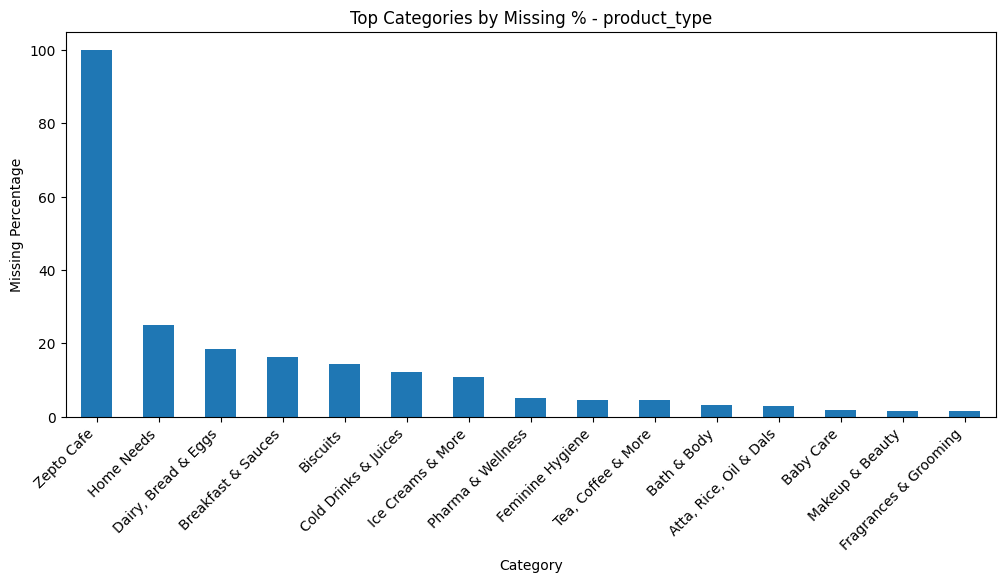

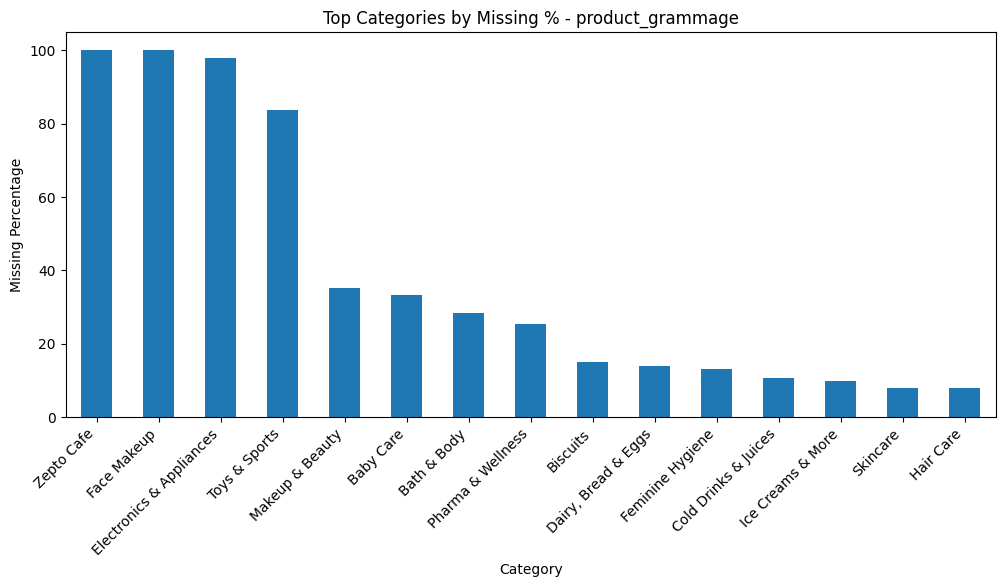

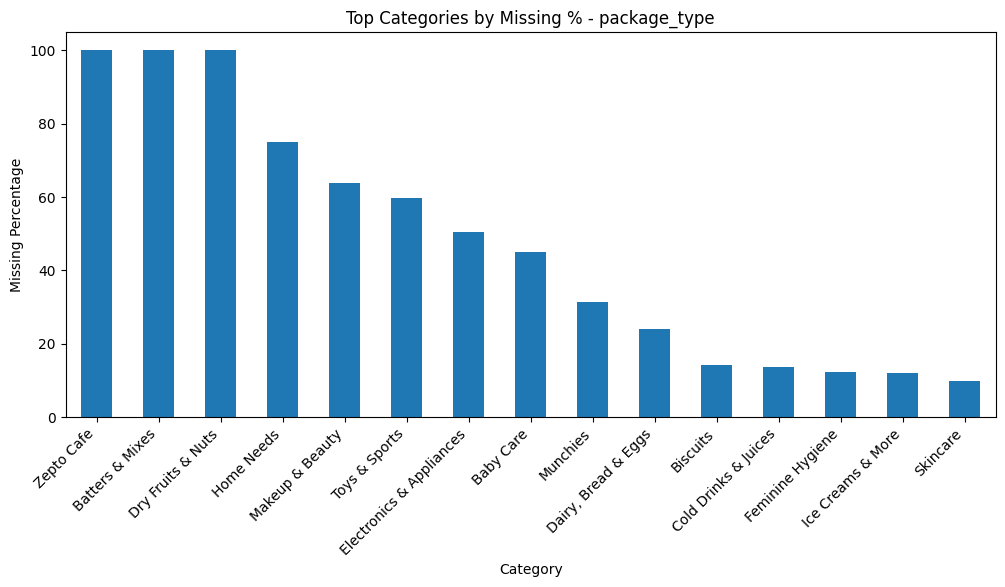

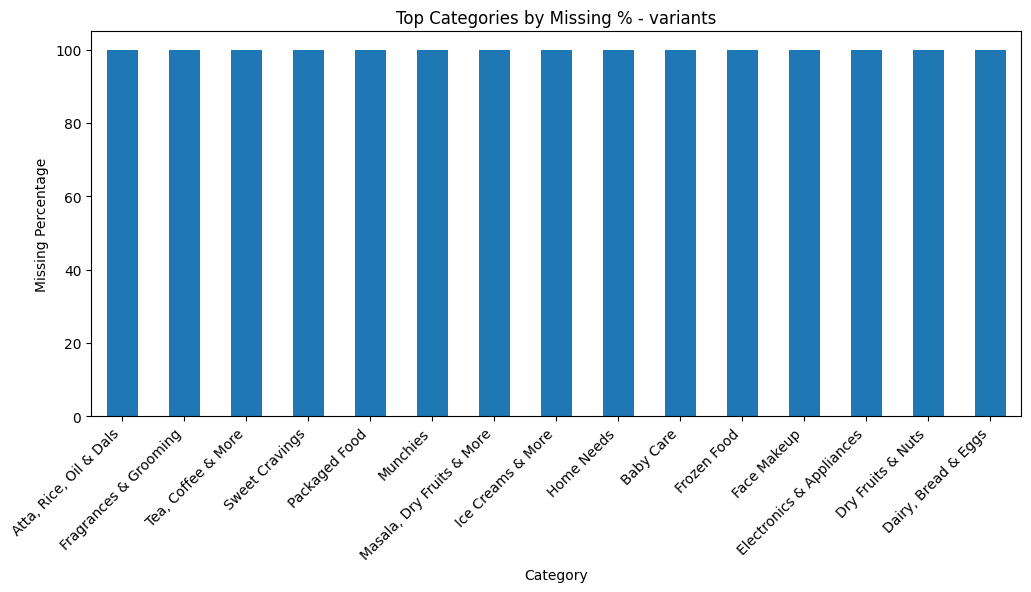

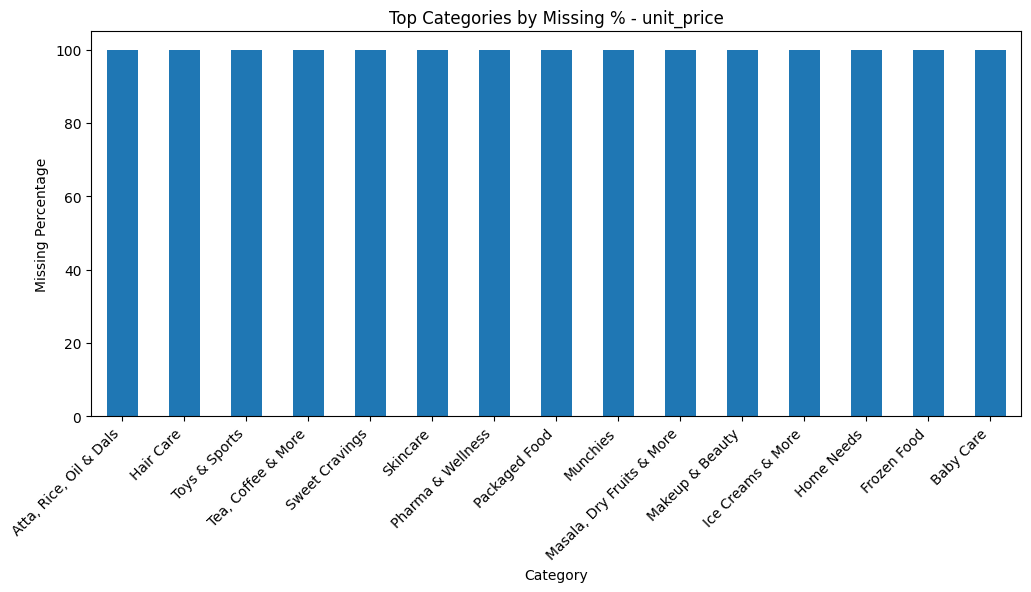

In [48]:
print("\nMISSING % BY CATEGORY - PLOTTING")
print("--------------------------------")

missing_cols = ['product_type', 'product_grammage', 'package_type', 'variants', 'unit_price']

# calculate missing %
category_missing = df.groupby('category')[missing_cols].apply(lambda x: x.isnull().mean() * 100)

# plot (one column at a time)
for col in missing_cols:
    plt.figure(figsize=(12,5))
    
    category_missing[col].sort_values(ascending=False).head(15).plot(kind='bar')
    
    plt.title(f"Top Categories by Missing % - {col}")
    plt.ylabel("Missing Percentage")
    plt.xlabel("Category")
    plt.xticks(rotation=45, ha='right')
    
    plt.show()


MISSING % BY CATEGORY - HEATMAP
--------------------------------


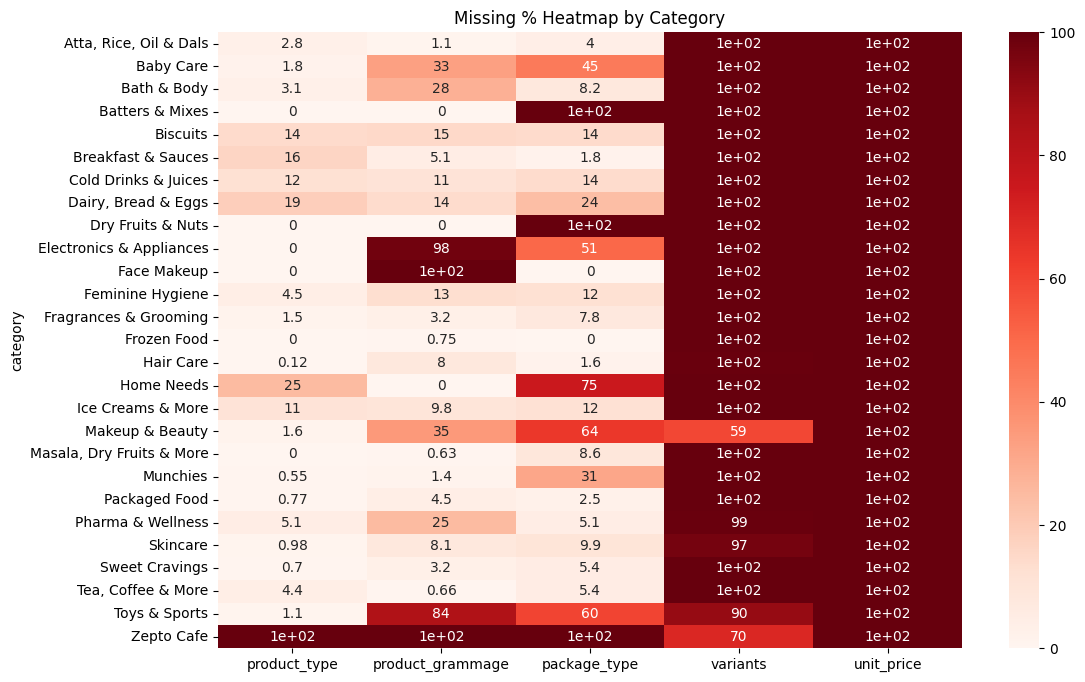

In [57]:
print("\nMISSING % BY CATEGORY - HEATMAP")
print("--------------------------------")


missing_heatmap = df.groupby('category')[missing_cols].apply(lambda x: x.isnull().mean() * 100)

plt.figure(figsize=(12,8))
sns.heatmap(missing_heatmap, annot=True, cmap='Reds')
plt.title("Missing % Heatmap by Category")
plt.show()

# NB: 'le+02' means 10^2, which is 100.



MISSING % BY STORE - HEATMAP
--------------------------------


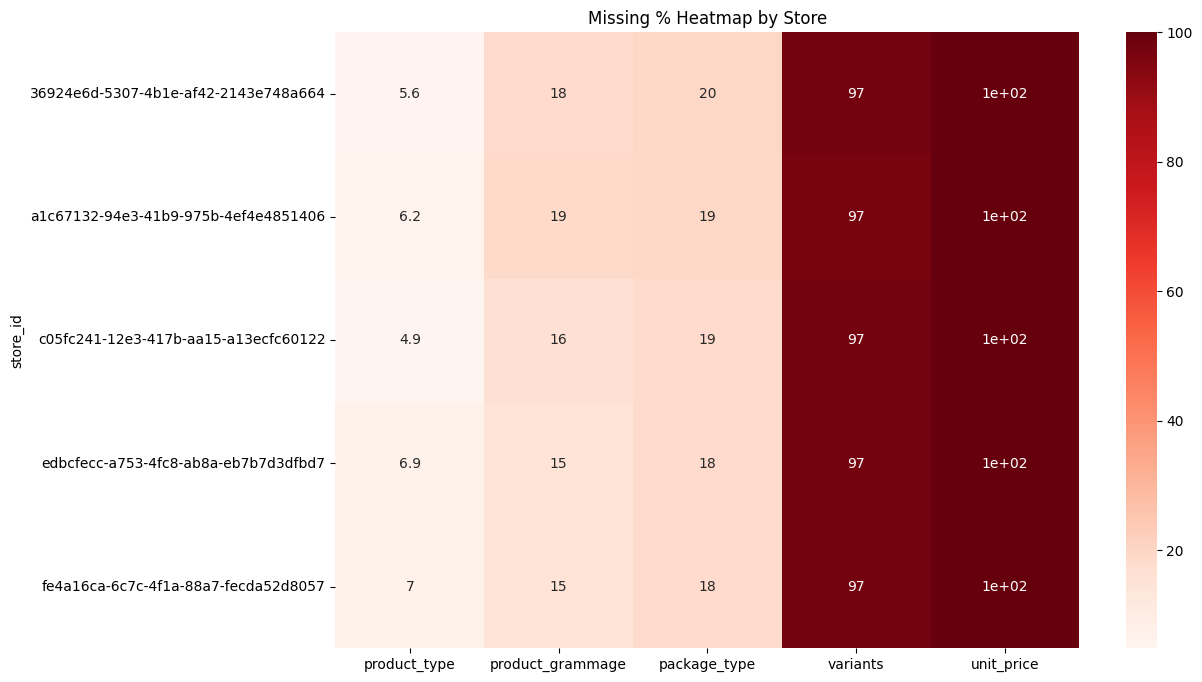

In [55]:
print("\nMISSING % BY STORE - HEATMAP")
print("--------------------------------")


missing_heatmap = df.groupby('store_id')[missing_cols].apply(lambda x: x.isnull().mean() * 100)

plt.figure(figsize=(12,8))
sns.heatmap(missing_heatmap, annot=True, cmap='Reds')
plt.title("Missing % Heatmap by Store")
plt.show()


MISSING % BY CITY - HEATMAP
--------------------------------


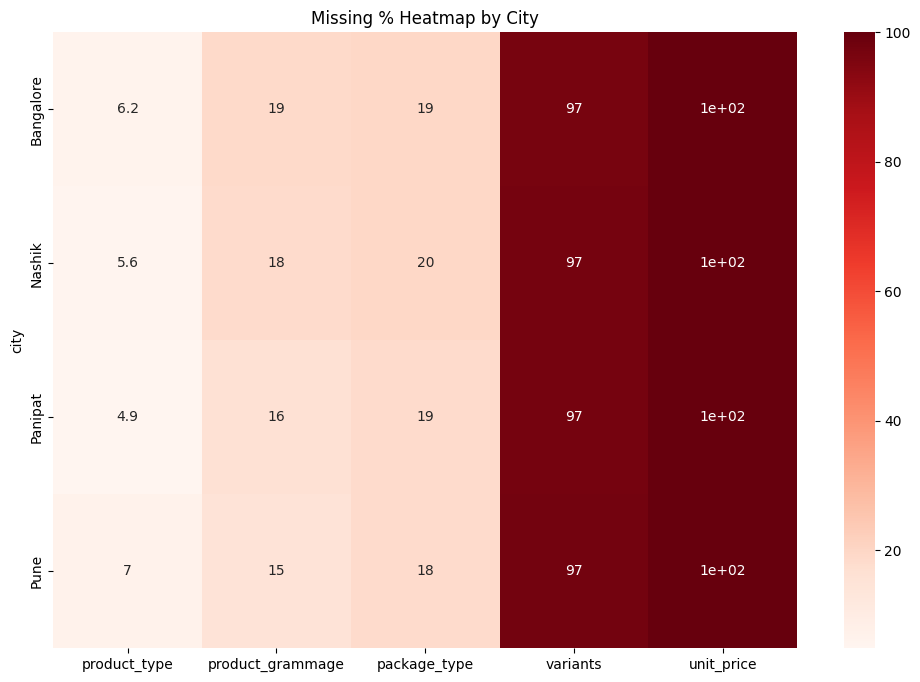

In [56]:
print("\nMISSING % BY CITY - HEATMAP")
print("--------------------------------")


missing_heatmap = df.groupby('city')[missing_cols].apply(lambda x: x.isnull().mean() * 100)

plt.figure(figsize=(12,8))
sns.heatmap(missing_heatmap, annot=True, cmap='Reds')
plt.title("Missing % Heatmap by City")
plt.show()

In [20]:
# products where product_type differs across cities
inconsistent_products = (
    df.groupby('product_name')['product_type']
      .nunique()
      .reset_index(name='type_count')
)

inconsistent_products = inconsistent_products[
    inconsistent_products['type_count'] > 1
]

print(inconsistent_products)

                                           product_name  type_count
31    4700BC Butter Popcorn | Jumbo Size | zero palm...           2
37    4700BC Devil popcorn | Jumbo size | zero palm oil           2
174         Akshayakalpa Artisanal Organic Set Curd Cup           2
217                           Amrut White Crystal Sugar           2
316                               Amul Masti Dahi Pouch           2
...                                                 ...         ...
6392                                   Urban White Eggs           2
6403                      Uttam Sugar Sulphurless Sugar           2
6525                                   Vijay White Eggs           2
6543                      Wagh Bakri Premium Spiced Tea           2
6751                           Z Magnetism For Men Talc           2

[105 rows x 2 columns]


***Insight :***
* unit_price is 100% missing, So the possible cause may be field not being sraped at all or mapping failure.
* The missing% of each column is almost equally distributed over each store. So it is not a single store problem, not regional issue, but it may be a  scraping issue.
* Data missing% is not uniform accross category, which is a critical isssue. 
* Zepto Cafe category has 100% missing on all the above fields which means data not mapped correctly or uses a completely different backend structure.
* All cities shows almost similar missing %, so it is not a problem of location.
* However columns with critical values like product_name, price, discount etc. are not missing.

**8)  Category Hierarchy Consistency**

In [21]:
print("\n DEPARTMENT - CATEGORY CONSISTENCY")
print("--------------------------------")

dept_category_map = df.groupby('department')['category'].unique()

for dept, cats in dept_category_map.items():
    print("\nDEPARTMENT:", dept)
    print("--------------------------------")
    print(list(cats))



 DEPARTMENT - CATEGORY CONSISTENCY
--------------------------------

DEPARTMENT: Atta, Rice & Dal
--------------------------------
['Atta, Rice, Oil & Dals']

DEPARTMENT: Baby Care
--------------------------------
['Baby Care', 'Packaged Food', 'Toys & Sports', 'Home Needs', 'Pharma & Wellness']

DEPARTMENT: Bakery & Biscuits
--------------------------------
['Packaged Food', 'Dairy, Bread & Eggs', 'Sweet Cravings', 'Biscuits']

DEPARTMENT: Beauty & Cosmetics
--------------------------------
['Skincare', 'Makeup & Beauty', 'Face Makeup', 'Fragrances & Grooming', 'Hair Care']

DEPARTMENT: Cold Drinks & Juices
--------------------------------
['Cold Drinks & Juices', 'Tea, Coffee & More', 'Dairy, Bread & Eggs', 'Zepto Cafe', 'Ice Creams & More', 'Pharma & Wellness']

DEPARTMENT: Dairy & Breakfast
--------------------------------
['Dairy, Bread & Eggs', 'Batters & Mixes', 'Breakfast & Sauces', 'Munchies', 'Packaged Food', 'Frozen Food', 'Sweet Cravings']

DEPARTMENT: Munchies
-----------

In [22]:
print("\n CATEGORY - SUBCATEGORY CONSISTENCY")
print("--------------------------------")

cat_subcat_map = df.groupby('category')['sub_category'].unique()

for cat, subcats in cat_subcat_map.items():
    print("\nCATEGORY:", cat)
    print("--------------------------------")
    print(list(subcats))


 CATEGORY - SUBCATEGORY CONSISTENCY
--------------------------------

CATEGORY: Atta, Rice, Oil & Dals
--------------------------------
['Besan, Sooji & Maida', 'Millets & Other Flours', 'Atta', 'Dals & Pulses', 'Rice & More', 'Oil', 'Ghee']

CATEGORY: Baby Care
--------------------------------
['Infant Clothing', 'Baby Gear', 'Baby & Mom Gifting', 'Baby Wipes', 'Baby Bath', 'Baby Diapering', 'Baby Feeding', 'Baby Health', 'Baby Safety', 'Baby Hygiene', 'Mom Care', 'Baby Oral Care', 'Baby Skin & Hair Care']

CATEGORY: Bath & Body
--------------------------------
['Gifting', 'Shower Gels', 'Soaps', 'Bath Accessories', 'Talcum Powder', 'Toothpaste', 'Toothbrush & More', 'Mouthwash']

CATEGORY: Batters & Mixes
--------------------------------
[nan]

CATEGORY: Biscuits
--------------------------------
['Cookies', 'Creamfills', 'Glucose & Marie', 'Digestives', 'Rusk & Khari', 'Wafers', 'Crackers']

CATEGORY: Breakfast & Sauces
--------------------------------
['Breakfast Cereals', 'Muesli 

In [23]:
print("\n SUBCATEGORY - PRODUCT TYPE CONSISTENCY")
print("--------------------------------")

subcat_prodtype_map = df.groupby('sub_category')['product_type'].unique()

for subcat, prodtypes in subcat_prodtype_map.items():
    print("\nSUBCATEGORY:", subcat)
    print("--------------------------------")
    print(list(prodtypes))


 SUBCATEGORY - PRODUCT TYPE CONSISTENCY
--------------------------------

SUBCATEGORY: Action Figures
--------------------------------
['Superhero Action Figure', 'Captain America Action Figure', 'Hulk Action Figure', 'Board Game', 'Character Action Figure', 'Press and Go Character Toy', 'Animal Action Figure Set', 'Batman Action Figure', 'Animal Action Figure', 'Toy Helicopter']

SUBCATEGORY: Activities & Outdoor Toys
--------------------------------
['Sling Hockey Board Game', 'Toy Blaster', 'Money Bank', 'Electric Water Blaster Gun', 'Pop and Catch Toy', 'Kids Swimming Pool', 'Water Gun', 'Foam Blaster Gun', 'Action Toy', 'Dart Shooter', 'Tabletop Game', 'Bubble Gun', 'Foam Bullet Blaster Gun', 'Kick Scooter', 'Construction Tool Set', 'Toy Gun', 'Foam Dart Bullets', 'Foam Dart Blaster', 'Inflatable Swimming Pool', 'Toy Foam Blaster', 'Table Tennis Trainer', 'Hover Football', 'Inflatable Pool', 'Duck Track Toy Set', 'Basketball Set', 'Archery Set', 'Spinning Top', 'Interactive Fidge

***Insights:***
* No specific inconsistencies noticed

**9) Suspicious values Checking**

In [13]:


def find_suspicious_values(df, column_name):
    suspicious_values = [
        'null', 'none', 'n/a', 'na', 'nil', 'not available',
        'not applicable', '-', '--', '0', ''
    ]
    
    mask = (
        df[column_name].isna() |
        df[column_name].astype(str).str.strip().str.lower().isin(suspicious_values) |
        df[column_name].str.fullmatch(r'\d+') |   # numeric only
        (df[column_name].str.len() < 3)    # too short
        )
    
    df_suspicious = df[mask]
    print(f"Number of suspicious values in '{column_name}': {len(df_suspicious)}")
    return df_suspicious[['unique_id', column_name]]

print(find_suspicious_values(df, 'product_name'))
print(find_suspicious_values(df, 'brand_name'))


Number of suspicious values in 'product_name': 0
Empty DataFrame
Columns: [unique_id, product_name]
Index: []
Number of suspicious values in 'brand_name': 11
                                  unique_id brand_name
3207   99556221-9b88-420d-9c1e-69d6716ab168          Z
3213   4fff9bb9-f225-46dd-ba34-53b8cae838bb          Z
7037   99556221-9b88-420d-9c1e-69d6716ab168          Z
10720  641e3be9-544f-4b94-8da9-dec232e6f90b          Z
10758  99556221-9b88-420d-9c1e-69d6716ab168          Z
11662  b01ce71b-cb04-4569-95f0-ebed29ad6de3        921
11679  2cebc141-7a38-4503-9842-92d933cd375f        921
14553  f76f5b37-f0bc-4f1b-b61a-d298566ace11         JO
14614  4fff9bb9-f225-46dd-ba34-53b8cae838bb          Z
17955  641e3be9-544f-4b94-8da9-dec232e6f90b          Z
17999  99556221-9b88-420d-9c1e-69d6716ab168          Z


**10) Price Anomalies**

In [16]:
def check_negative_and_zero(df, column):
    """
    Returns rows where the given column has:
    - negative values (< 0)
    - zero values (== 0)
    """

    # Ensure numeric (safe for real-world messy data)
    df[column] = pd.to_numeric(df[column], errors='coerce')

    negative_values = df[df[column] < 0]
    zero_values = df[df[column] == 0]

    return {
        "negative_values": negative_values[['unique_id', column]],
        "zero_values": zero_values[['unique_id', column]]
    }

print("\nItem MRP:")
print(check_negative_and_zero(df, 'item_mrp'))
print("\nItem Selling Price:")
print(check_negative_and_zero(df, 'item_selling_price'))
print("\nProduct Price:")
print(check_negative_and_zero(df, 'product_price'))
print("\nPromo Offer Price:")
print(check_negative_and_zero(df, 'promo_offer_price'))


Item MRP:
{'negative_values': Empty DataFrame
Columns: [unique_id, item_mrp]
Index: [], 'zero_values': Empty DataFrame
Columns: [unique_id, item_mrp]
Index: []}

Item Selling Price:
{'negative_values': Empty DataFrame
Columns: [unique_id, item_selling_price]
Index: [], 'zero_values': Empty DataFrame
Columns: [unique_id, item_selling_price]
Index: []}

Product Price:
{'negative_values': Empty DataFrame
Columns: [unique_id, product_price]
Index: [], 'zero_values': Empty DataFrame
Columns: [unique_id, product_price]
Index: []}

Promo Offer Price:
{'negative_values': Empty DataFrame
Columns: [unique_id, promo_offer_price]
Index: [], 'zero_values': Empty DataFrame
Columns: [unique_id, promo_offer_price]
Index: []}


In [19]:
# check if item_selling_price is greater than item_mrp
df[df['item_selling_price'] > df['item_mrp']][['unique_id', 'item_selling_price', 'item_mrp']]

,unique_id,item_selling_price,item_mrp


In [21]:
# check if discount_in_percent is greater than 0 and item_selling_price is greater than or equal to item_mrp
df[
    (df['discount_in_percent'] > 0) &
    (df['item_selling_price'] >= df['item_mrp'])
][['unique_id', 'item_selling_price', 'item_mrp', 'discount_in_percent']]

,unique_id,item_selling_price,item_mrp,discount_in_percent


In [22]:
# check if promo_offer_description is not null and promo_offer_price is null
df[
    (df['promo_offer_description'].notnull()) &

    (df['promo_offer_price'].isnull())][['unique_id', 'promo_offer_description', 'promo_offer_price']]

,unique_id,promo_offer_description,promo_offer_price


In [23]:
# check if promo_offer_price is not null and promo_offer_price is not equal to item_selling_price
df[
    (df['promo_offer_price'].notnull()) &
    (df['promo_offer_price'] != df['item_selling_price'])
][['unique_id', 'promo_offer_description', 'promo_offer_price', 'item_selling_price']]

,unique_id,promo_offer_description,promo_offer_price,item_selling_price


In [ ]:
# check if out_of_stock_flag is True and stock_count is greater than 0
df[
    (df['out_of_stock_flag'] == True) &
    (df['stock_count'] > 0)
][['unique_id', 'store_id', 'product_id_upc_ean']]

,unique_id,store_id,product_id_upc_ean


***Insights:***
* No specific anomalies found on price related columns
* All such columns are greater than 0.
* selling price and mrp are equal.
* selling price is always less than mrp if discount percentage exists.
* if promo offer description exists, promo offer price also exists.
* If out of stock flag true, stock count is zero.

**11) URL Checking**

In [34]:
total_records = len(df)
missing_urls = df['product_url'].isnull().sum()
unique_urls = df['product_url'].nunique(dropna=True)
duplicate_urls = df['product_url'].duplicated().sum()

print("URL ANALYSIS SUMMARY")
print("-" * 40)
print(f"Total records           : {total_records}")
print(f"Missing URLs            : {missing_urls}")
print(f"Unique URLs             : {unique_urls}")
print(f"Duplicate URLs          : {duplicate_urls}")
print(f"Uniqueness %            : {(unique_urls/total_records)*100:.2f}%")






URL ANALYSIS SUMMARY
----------------------------------------
Total records           : 19034
Missing URLs            : 0
Unique URLs             : 7552
Duplicate URLs          : 11482
Uniqueness %            : 39.68%

Duplicate URL Records:
                                  unique_id  \
17464  adaa7f1e-5789-422d-8e93-aea588f38362   
4063   adaa7f1e-5789-422d-8e93-aea588f38362   
7891   adaa7f1e-5789-422d-8e93-aea588f38362   
6746   eeccd781-2f48-4028-af3a-f95a7c230819   
2859   eeccd781-2f48-4028-af3a-f95a7c230819   

                                       product_name  \
17464                24 Mantra Organic 7 Grain Atta   
4063                 24 Mantra Organic 7 Grain Atta   
7891                 24 Mantra Organic 7 Grain Atta   
6746   24 Mantra Organic Active Mantras Low Gi Rice   
2859   24 Mantra Organic Active Mantras Low Gi Rice   

                                             product_url  
17464  https://www.zepto.com/pn/24-mantra-organic-7-g...  
4063   https://www.zepto.c

In [35]:
# ----------------------------
# Duplicate URL Records
# ----------------------------
duplicate_url_df = df[
    df['product_url'].duplicated(keep=False)
].sort_values('product_url')

print("\nDuplicate URL Records:")
print(duplicate_url_df[['unique_id', 'product_name', 'product_url']].head())


Duplicate URL Records:
                                  unique_id  \
17464  adaa7f1e-5789-422d-8e93-aea588f38362   
4063   adaa7f1e-5789-422d-8e93-aea588f38362   
7891   adaa7f1e-5789-422d-8e93-aea588f38362   
6746   eeccd781-2f48-4028-af3a-f95a7c230819   
2859   eeccd781-2f48-4028-af3a-f95a7c230819   

                                       product_name  \
17464                24 Mantra Organic 7 Grain Atta   
4063                 24 Mantra Organic 7 Grain Atta   
7891                 24 Mantra Organic 7 Grain Atta   
6746   24 Mantra Organic Active Mantras Low Gi Rice   
2859   24 Mantra Organic Active Mantras Low Gi Rice   

                                             product_url  
17464  https://www.zepto.com/pn/24-mantra-organic-7-g...  
4063   https://www.zepto.com/pn/24-mantra-organic-7-g...  
7891   https://www.zepto.com/pn/24-mantra-organic-7-g...  
6746   https://www.zepto.com/pn/24-mantra-organic-act...  
2859   https://www.zepto.com/pn/24-mantra-organic-act...  


In [36]:

# ----------------------------
# URL Format Validation
# ----------------------------

# Regex for HTTP/HTTPS URLs
url_pattern = re.compile(
    r'^(https?://)'               # http:// or https://
    r'([\w.-]+)'                  # domain
    r'(\.[a-zA-Z]{2,})'           # TLD
    r'([/\w .?%&=+-]*)?$'         # path/query
)

invalid_urls = df[
    df['product_url'].notnull() &
    ~df['product_url'].astype(str).str.match(url_pattern)
]

print("\nInvalid URL Format Count:", len(invalid_urls))

print("\nSample Invalid URLs:")
print(
    invalid_urls[
        ['unique_id', 'product_name', 'product_url']
    ].head(10)
)


Invalid URL Format Count: 0

Sample Invalid URLs:
Empty DataFrame
Columns: [unique_id, product_name, product_url]
Index: []


In [37]:

# ----------------------------
# URLs without http/https
# ----------------------------
missing_protocol = df[
    df['product_url'].notnull() &
    ~df['product_url'].astype(str).str.startswith(('http://', 'https://'))
]

print("\nURLs missing protocol (http/https):", len(missing_protocol))

print(
    missing_protocol[
        ['unique_id', 'product_name', 'product_url']
    ].head()
)


URLs missing protocol (http/https): 0
Empty DataFrame
Columns: [unique_id, product_name, product_url]
Index: []


***Insights***
* Format and pattern of urls are correct
* But 11482 duplicate urls present on the dataset.
* These duplcates have different store location and different price range.

**12) City, Store, Pincode Analysis**

In [77]:
# Missing percentage by city

missing_by_city = (
    df.groupby('city')
      .apply(lambda x: x.isnull().mean().mean() * 100)
      .reset_index(name='missing_perc')
      .sort_values('missing_perc', ascending=False)
)

# Stockout percentage by city

df['out_of_stock_flag_num'] = (
    df['out_of_stock_flag']
    .astype(str)
    .str.lower()
    .isin(['true', 'yes', '1', 'y'])
    .astype(int)
)

stockout_by_city = (
    df.groupby('city')['out_of_stock_flag_num']
      .mean()
      .mul(100)
      .reset_index(name='stockout_perc')
      .sort_values('stockout_perc', ascending=False)
)

# Discount percentage by city

discount_by_city = (
    df.groupby('city')['discount_in_percent']
      .mean()
      .reset_index(name='avg_discount_perc')
      .sort_values('avg_discount_perc', ascending=False)
) 

# Number of unique products by city

products_by_city = (
    df.groupby('city')['unique_id']
      .nunique()
      .reset_index(name='product_count')
      .sort_values('product_count', ascending=False)
)

# Combine all metrics
city_analysis = (
    missing_by_city
    .merge(stockout_by_city, on='city', how='outer')
    .merge(discount_by_city, on='city', how='outer')
    .merge(products_by_city, on='city', how='outer')
    .sort_values('missing_perc', ascending=False)
)

print("\nCITY ANALYSIS SUMMARY")
print("--------------------------------")
print(city_analysis)


CITY ANALYSIS SUMMARY
--------------------------------
        city  missing_perc  stockout_perc  avg_discount_perc  product_count
0  Bangalore      7.545562      29.506571          20.071907           4033
1     Nashik      7.526443      24.001045          19.258292           3829
3       Pune      7.437883      30.115725          19.095984           3705
2    Panipat      7.404625      16.906193          18.646982           3827


/tmp/ipykernel_14896/439306221.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isnull().mean().mean() * 100)


In [78]:
# Missing percentage by store

missing_by_store = (
    df.groupby('store_id')
      .apply(lambda x: x.isnull().mean().mean() * 100)
      .reset_index(name='missing_perc')
      .sort_values('missing_perc', ascending=False)
)

# Stockout percentage by store

df['out_of_stock_flag_num'] = (
    df['out_of_stock_flag']
    .astype(str)
    .str.lower()
    .isin(['true', 'yes', '1', 'y'])
    .astype(int)
)

stockout_by_store = (
    df.groupby('store_id')['out_of_stock_flag_num']
      .mean()
      .mul(100)
      .reset_index(name='stockout_perc')
      .sort_values('stockout_perc', ascending=False)
)

# Discount percentage by store

discount_by_store = (
    df.groupby('store_id')['discount_in_percent']
      .mean()
      .reset_index(name='avg_discount_perc')
      .sort_values('avg_discount_perc', ascending=False)
) 

# Number of unique products by store

products_by_store = (
    df.groupby('store_id')['unique_id']
      .nunique()
      .reset_index(name='product_count')
      .sort_values('product_count', ascending=False)
)

# Combine all metrics
store_analysis = (
    missing_by_store
    .merge(stockout_by_store, on='store_id', how='outer')
    .merge(discount_by_store, on='store_id', how='outer')
    .merge(products_by_store, on='store_id', how='outer')
    .sort_values('missing_perc', ascending=False)
)

print("\nSTORE ANALYSIS SUMMARY")
print("--------------------------------")
print(store_analysis)


STORE ANALYSIS SUMMARY
--------------------------------
                               store_id  missing_perc  stockout_perc  \
1  a1c67132-94e3-41b9-975b-4ef4e4851406      7.545562      29.506571   
0  36924e6d-5307-4b1e-af42-2143e748a664      7.526443      24.001045   
4  fe4a16ca-6c7c-4f1a-88a7-fecda52d8057      7.441406      31.983696   
3  edbcfecc-a753-4fc8-ab8a-eb7b7d3dfbd7      7.434345      28.240109   
2  c05fc241-12e3-417b-aa15-a13ecfc60122      7.404625      16.906193   

   avg_discount_perc  product_count  
1          20.071907           4033  
0          19.258292           3829  
4          18.973098           3680  
3          19.219372           3665  
2          18.646982           3827  


/tmp/ipykernel_14896/939501608.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isnull().mean().mean() * 100)


In [79]:
# Missing percentage by pincode

missing_by_pincode = (
    df.groupby('pin_code')
      .apply(lambda x: x.isnull().mean().mean() * 100)
      .reset_index(name='missing_perc')
      .sort_values('missing_perc', ascending=False)
)

# Stockout percentage by pincode

df['out_of_stock_flag_num'] = (
    df['out_of_stock_flag']
    .astype(str)
    .str.lower()
    .isin(['true', 'yes', '1', 'y'])
    .astype(int)
)

stockout_by_pincode = (
    df.groupby('pin_code')['out_of_stock_flag_num']
      .mean()
      .mul(100)
      .reset_index(name='stockout_perc')
      .sort_values('stockout_perc', ascending=False)
)

# Discount percentage by pincode

discount_by_pincode = (
    df.groupby('pin_code')['discount_in_percent']
      .mean()
      .reset_index(name='avg_discount_perc')
      .sort_values('avg_discount_perc', ascending=False)
) 

# Number of unique products by pincode

products_by_pincode = (
    df.groupby('pin_code')['unique_id']
      .nunique()
      .reset_index(name='product_count')
      .sort_values('product_count', ascending=False)
)

# Combine all metrics
pincode_analysis = (
    missing_by_pincode
    .merge(stockout_by_pincode, on='pin_code', how='outer')
    .merge(discount_by_pincode, on='pin_code', how='outer')
    .merge(products_by_pincode, on='pin_code', how='outer')
    .sort_values('missing_perc', ascending=False)
)

print("\nPINCODE ANALYSIS SUMMARY")
print("--------------------------------")
print(pincode_analysis)


PINCODE ANALYSIS SUMMARY
--------------------------------
   pin_code  missing_perc  stockout_perc  avg_discount_perc  product_count
1    411017      9.677419      16.129032          22.709677             31
2    411027      7.648402     100.000000          21.093607            438
5    560091      7.545562      29.506571          20.071907           4033
4    422006      7.526443      24.001045          19.258292           3829
3    411057      7.414376      25.727167          18.952443           3677
0    132103      7.404625      16.906193          18.646982           3827


/tmp/ipykernel_14896/3770454122.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isnull().mean().mean() * 100)


***Insights***
* Missing percentage are almost equally distributed over city, store and pincode.
* Stockout% is little high at Bangalore city, and moderately distributed over other cities, stores and pincodes
* stockout % is 100% on pin_code 411027 and while checking on website, some of these products are able to add to cart, while some others can't. Anyway we can infer some problems may exist on the supply to that particular pincode.
* Discount % is also little high on Bangalore and moderately distributed over other cities, stores and pincodes.
* Product count is also little high on Bangalore, first store_id and moderately distributed over other cities, stores. 
* In case of pincode, 411017 and 411027 has very less number of products available.


**13) High Price Variation**

In [ ]:
# Price Variation Analysis
price_variation = (
    df.groupby('product_id_upc_ean')
      .agg(
          product_name=('product_name', 'first'),
          min_price=('item_selling_price', 'min'),
          max_price=('item_selling_price', 'max'),
          mean_price=('item_selling_price', 'mean'),
          num_locations=('city', 'nunique')
      )
      .reset_index()
)

# Calculate percentage variation
price_variation['price_variation_pct'] = (
    (price_variation['max_price'] - price_variation['min_price'])
    / price_variation['min_price'] * 100
).round(2)

# Flag products having >30% variation
high_variation = price_variation[
    price_variation['price_variation_pct'] > 30
].sort_values('price_variation_pct', ascending=False)

print(high_variation.head(20))

                        product_id_upc_ean  \
5138  b77068c0-47d7-4d45-9a0e-c9e4d20d7da4   
6261  ddfb97da-15b2-4883-a3fb-19fb27b78869   
6255  ddcfcab4-3372-4325-893a-80180cc6f43d   
1602  39257b6d-769d-4808-af1b-b9111b8a912d   
923   20c928c1-3a78-4d00-9177-dc90f72223d2   
96    02f45221-ff1f-4bb8-8fa4-5bff95f3d65c   
6105  d8f9e276-3ba5-4cd8-a3b3-35366aa03432   
6702  ecffd786-9be2-4f5d-b66d-01021dcd00ac   
7218  fde43d16-7e6c-4fe1-bde5-e5fc3d7ca59a   
6175  db014b60-9375-42eb-a941-c1922d537b87   
1169  2a03cdf6-326c-40bd-9820-99abbcab049b   
3262  747b3de4-5f37-4ec2-82ae-13c17a66792b   
2560  5c3defd8-76d0-49ee-b27d-52f126734881   
7073  f95e321c-7188-42cd-861a-0d946a66fd67   
2643  5f774429-1248-4bc4-a31e-61e7eb4b1c6b   
7277  ff98e135-9e46-4196-80f4-b455505bed73   
1239  2c4f7add-98be-4719-b6a4-5200b8679f1f   
3791  86fc34c4-902f-4ded-ad66-321222a6308b   
2509  5a20b3c1-0103-4f15-adf6-a30e0e341c45   
4875  adfb6c5b-bfd7-4613-acc5-7110a5509752   

                                 

In [25]:
# check if any product has more than one selling price with same grammage across different stores
price_variation = (
    df.groupby(['product_name', 'product_grammage'])['item_selling_price']
      .nunique()
      .reset_index(name='price_count')
)

# Keep only products having more than one selling price
price_variation = price_variation[
    price_variation['price_count'] > 1
]

print(price_variation)

                                       product_name product_grammage  \
2                    24 Mantra Organic 7 Grain Atta             5 kg   
10                    24 Mantra Organic Low Gi Rice             2 kg   
11                    24 Mantra Organic Low Gi Rice             5 kg   
14                           24 Mantra Organic Poha            500 g   
15                    24 Mantra Organic Puffed Rice            200 g   
...                                             ...              ...   
6076                    iD Fresh Idli & Dosa Batter            500 g   
6079                        iD Fresh Organic Batter            500 g   
6083        iD Fresh Ragi Millet Idly & Dosa Batter            500 g   
6100    mCaffeine Coffee Hydrogel Under Eye Patches           30 pcs   
6104  mCaffeine Take A Dip 3 in 1 Perfume Body Wash           250 ml   

      price_count  
2               2  
10              3  
11              4  
14              2  
15              3  
...           .

In [ ]:
# Group by product_name and product_grammage and find price varation statistics
price_analysis = (
    df.groupby(['product_name', 'product_grammage'])['item_selling_price']
      .agg(['count', 'min', 'max', 'mean', 'std'])
      .reset_index()
)

# Calculate price difference and percentage variation
price_analysis['price_diff'] = (
    price_analysis['max'] - price_analysis['min']
)

price_analysis['pct_variation'] = (
    (price_analysis['price_diff'] / price_analysis['mean']) * 100
).round(2)

# Flag products with >20% variation
high_variation = price_analysis[
    price_analysis['pct_variation'] > 20
].sort_values('pct_variation', ascending=False)

print(high_variation)

                                           product_name product_grammage  \
4909  Sanfe Hair Styling Spray Fast Drying Formula, ...             50 g   
5155                       Sprite Lemon Plus Zero Sugar           320 ml   
409   Arata Medium Hold Styling Cream with Hyaluroni...            50 ml   
2232  Go Zero Madagascar Chocolate Guilt Free Ice Cr...            70 ml   
3621                Modern Sandwich Supreme White Bread            400 g   
...                                                 ...              ...   
5771  Vaseline Cocoa Glow Serum In Lotion100% Pure C...           400 ml   
1849          Epigamia 17g Protein Turbo Yogurt Natural            140 g   
5895  Whisper Super Absorbent Period Panty, 6 M-L Pants            6 pcs   
6074                        iD Fresh Idli & Dosa Batter             1 kg   
3400  Mamypoko Extra Absorb Pant Style Diaper | XL |...           52 pcs   

      count    min    max        mean         std  price_diff  pct_variation  
4909    

In [29]:
# check if any product has more than one selling price with same grammage on same store
price_variation = (
    df.groupby(['store_name_location', 'product_name', 'product_grammage'])['item_selling_price']
      .agg(['min', 'max', 'nunique', 'count'])
      .reset_index()
)

# Keep only products having more than one unique selling price
price_variation = price_variation[
    price_variation['nunique'] > 1
]

# Calculate price difference
price_variation['price_difference'] = (
    price_variation['max'] - price_variation['min']
)

print(price_variation.sort_values('price_difference', ascending=False))

                                     store_name_location  \
6277   Kalpataru New Launch Pimple Nilakh, Jagtap Dai...   
382    Blinkit Store HP-2, Phase 2, Hinjawadi Rajiv G...   
3103   Blinkit Store HP-2, Phase 2, Hinjawadi Rajiv G...   
6276   Kalpataru New Launch Pimple Nilakh, Jagtap Dai...   
11896  Ridhs Academy, Ridh's Academy, Near Vidya Samr...   
5839   Hotel Tarangan, 2, Kharjul Mala, Takli Road Ja...   
4258   Hotel Tarangan, 2, Kharjul Mala, Takli Road Ja...   
1150   Blinkit Store HP-2, Phase 2, Hinjawadi Rajiv G...   
11011  Ridhs Academy, Ridh's Academy, Near Vidya Samr...   
14098  Sky Fly Trampoline Park, Shankar Kalat Nagar, ...   
1962   Blinkit Store HP-2, Phase 2, Hinjawadi Rajiv G...   
14795  Sky Fly Trampoline Park, Shankar Kalat Nagar, ...   
11467  Ridhs Academy, Ridh's Academy, Near Vidya Samr...   
7747   Modal Tawn, 1108, Sector 18 Rd, Sector - 18, H...   
869    Blinkit Store HP-2, Phase 2, Hinjawadi Rajiv G...   
10709  Ridhs Academy, Ridh's Academy, Ne

***Insights***
* Huge variation is present in some products. But while checking on the website, the product_grammage is different for each prices of the same product.
* Also checked whether same product with same grammage has different item_selling_price and found 17 such products. But the urls are different and the discount is also different. But it seems to be a wrong pattern




**14) Outlier Detection**

In [81]:
columns = [
    'item_mrp',
    'item_selling_price',
    'discount_in_percent',
    'stock_count',
    'net_quantity'
]

for col in columns:

    print(f"\n{'='*60}")
    print(f"OUTLIER ANALYSIS: {col}")
    print(f"{'='*60}")

    # Convert to numeric
    df[col] = pd.to_numeric(df[col], errors='coerce')

    # Remove nulls for analysis
    temp = df[df[col].notnull()]

    # Calculate IQR
    Q1 = temp[col].quantile(0.25)
    Q3 = temp[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find outliers
    outliers = temp[
        (temp[col] < lower_bound) |
        (temp[col] > upper_bound)
    ]

    print(f"Q1               : {Q1}")
    print(f"Q3               : {Q3}")
    print(f"IQR              : {IQR}")
    print(f"Lower Bound      : {lower_bound}")
    print(f"Upper Bound      : {upper_bound}")
    print(f"Outlier Count    : {len(outliers)}")
    print(f"Outlier %        : {len(outliers)/len(temp)*100:.2f}%")

    # Display sample outliers
    print("\nSample Outliers:")
    print(
        outliers[
            ['unique_id', 'product_name', col]
        ].head(10)
    )


OUTLIER ANALYSIS: item_mrp
Q1               : 90.0
Q3               : 400.0
IQR              : 310.0
Lower Bound      : -375.0
Upper Bound      : 865.0
Outlier Count    : 1598
Outlier %        : 8.40%

Sample Outliers:
                                unique_id  \
128  29043823-7e55-4e8d-b2fe-5bdd4cf9c8c0   
137  bb3437d0-568b-41b5-81cd-d01db7af7804   
138  2da2dcca-ab8e-4e00-afbc-7dd0652fcaca   
144  77bfe56c-9477-464d-808f-f278447532c8   
150  5cff5036-c1fe-4cdb-a67f-34c30ba989a0   
151  1de4add4-6913-4493-8c8a-623a9f93611c   
152  2e3dc1b7-a552-4ea4-a7fc-09e04439b66e   
154  39b3df57-2ef9-40f4-b0b4-d3b7d7195e3b   
156  f7743c4f-e1c4-4d1f-b795-e8c275561824   
158  fa68f00e-15e0-4a02-ae7d-386858337f39   

                                          product_name  item_mrp  
128                            GTS Original Kolam Rice    1150.0  
137      India Gate Classic Gold Standard Basmati Rice    1295.0  
138             Daawat Super Basmati Rice | Long Grain     995.0  
144             

ZeroDivisionError: division by zero

** INSIGHTS**
-------------------
    * Shape of dataset is (19034, 31), with only the column unit_price is completely empty.
    * All columns including unique_id are not unique in the dataset. A subset of ['unique_id', 'store_id','product_id_upc_ean'] found to be unique
    * Dataset contains 1243 rows with same product_name and same store_id, which means product duplication. But while evaluated the products, net_quantity and discount_in_percentage is different. Need to reevaluate this case.
    * 